# 03 — Investment Screening Rules

Notebook 01 showed that the Glassdoor outlook signal is statistically real
but weak on its own. The natural way to use a weak-but-real factor is
inside a **multi-rule screen**. The original research documented eight rules
but never implemented them; here they are implemented in
`quantlab.screening` and applied to the full 2020 universe.

**Result:** 15 of ~1,170 companies pass 7 of 8 rules — a focused diligence
list including Apple, Microsoft, Nvidia, Adobe and Amazon (as of Dec 2020).

## The rules

| # | Rule | Rationale / source |
|---|------|--------------------|
| 1 | Net income per employee ≥ $10,000 | Productivity floor (own rule) |
| 2 | Profit margin > 2.57% | Buffett-style moat proxy |
| 3 | 3-, 5-, 10-year ROI all > 10.1% | Sustained compounding across horizons |
| 4 | Upward price trend | Don't fight the tape (own rule) |
| 5 | Glassdoor outlook ≥ 60% | Employees are confident in the future (notebook 01) |
| 6 | Glassdoor rating ≥ 3.5 | Employees speak well of the company |
| 7 | 0 ≤ PEG ≤ 1 | Growth-adjusted undervaluation (Buffett/Lynch) |
| 8 | Beats S&P 500 over 1 and 5 years | Must out-earn the passive alternative |

In [1]:
import matplotlib.pyplot as plt

from quantlab.data import load_prices
from quantlab.data.fundamentals import load_research_universe
from quantlab.screening import apply_rules, default_rules

plt.rcParams["figure.figsize"] = (10, 5)

## Rule 8 needs market benchmarks

"Beats the S&P 500" requires the S&P's trailing 1-year and 5-year annualized
returns *as of the December 2020 snapshot date*, computed from the cached SPY
price history rather than hardcoded.

In [2]:
SNAPSHOT_DATE = "2020-12-24"
spy = load_prices("SPY", "2015-12-24", SNAPSHOT_DATE)["SPY"]

sp500_1yr = (spy.iloc[-1] / spy.loc[:"2019-12-24"].iloc[-1] - 1) * 100
years = (spy.index[-1] - spy.index[0]).days / 365.25
sp500_5yr = ((spy.iloc[-1] / spy.iloc[0]) ** (1 / years) - 1) * 100
print(f"S&P 500 trailing 1-year return : {sp500_1yr:.2f}%")
print(f"S&P 500 trailing 5-year return : {sp500_5yr:.2f}% annualized")

S&P 500 trailing 1-year return : 17.02%
S&P 500 trailing 5-year return : 14.59% annualized


## Applying the screen

In [3]:
universe = load_research_universe()
rules = default_rules(sp500_1yr=sp500_1yr, sp500_5yr=sp500_5yr)
for rule in rules:
    print(f"- {rule.description}")

screened = apply_rules(universe, rules)

- Net income per employee >= $10,000
- Net profit margin > 2.57%
- 3-, 5-, and 10-year trailing ROI all > 10.1%
- Price shows an upward trend
- Glassdoor positive business outlook >= 60%
- Glassdoor overall rating >= 3.5
- PEG ratio between 0 and 1 (growth-adjusted undervaluation)
- Beats S&P 500 over 1 year (> 17.0%) and 5 years (> 14.6%)


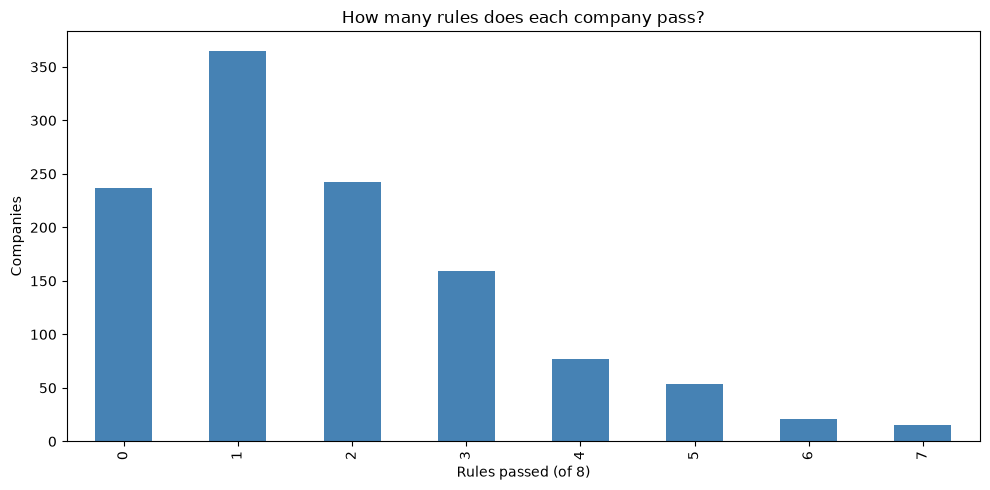

In [4]:
from pathlib import Path
Path("../docs/img").mkdir(parents=True, exist_ok=True)
counts = screened["rules_passed"].value_counts().sort_index()
ax = counts.plot.bar(color="steelblue")
ax.set_title("How many rules does each company pass?")
ax.set_xlabel("Rules passed (of 8)")
ax.set_ylabel("Companies")
plt.tight_layout()
plt.savefig("../docs/img/03_rules_passed_distribution.png", dpi=120)
plt.show()


## The candidate list

No company passes all eight rules in December 2020 — rule 7 (PEG ≤ 1) and
rule 5 (outlook ≥ 60) rarely coincide, which is itself informative: the
market already prices employee optimism. The top tier passes 7 of 8.

In [5]:
display_cols = [
    "ticker",
    "security",
    "sector",
    "rules_passed",
    "outlook",
    "rating",
    "profit_margin",
    "peg",
    "five_year",
    "net_per_emp",
]
top = screened[screened["rules_passed"] >= 7][display_cols]
top.round(2)

,ticker,security,sector,rules_passed,outlook,rating,profit_margin,peg,five_year,net_per_emp
0,AAPL,Apple,Technology,7,76,4.2,20.91,3.3,37.7,419058.39
1,ADBE,Adobe Systems,Technology,7,87,4.3,31.05,2.5,39.72,170584.08
2,ALGN,AlignTech (Invisalign),Healthcare,7,84,4.4,75.99,4.0,52.01,119614.59
3,AMZN,Amazon.com,Consumer Cyclical,7,71,3.9,4.99,1.3,36.96,21775.69
4,AVGO,Broadcom,Technology,7,60,3.5,11.15,1.1,26.0,155789.47
5,DASTY,Dassault Systemes SE ADR,Technology,7,84,3.9,10.65,3.2,20.24,23500.0
6,MSFT,Microsoft,Technology,7,75,4.3,32.29,2.6,32.98,291386.5
7,NFLX,Netflix,Consumer Cyclical,7,77,4.0,11.78,2.3,36.44,326279.07
8,NVDA,Nvidia,Technology,7,87,4.8,25.89,2.9,73.58,277749.55
9,SNPS,Synopsys,Technology,7,77,4.0,18.03,3.3,41.56,47783.53


### Which rule is the binding constraint?

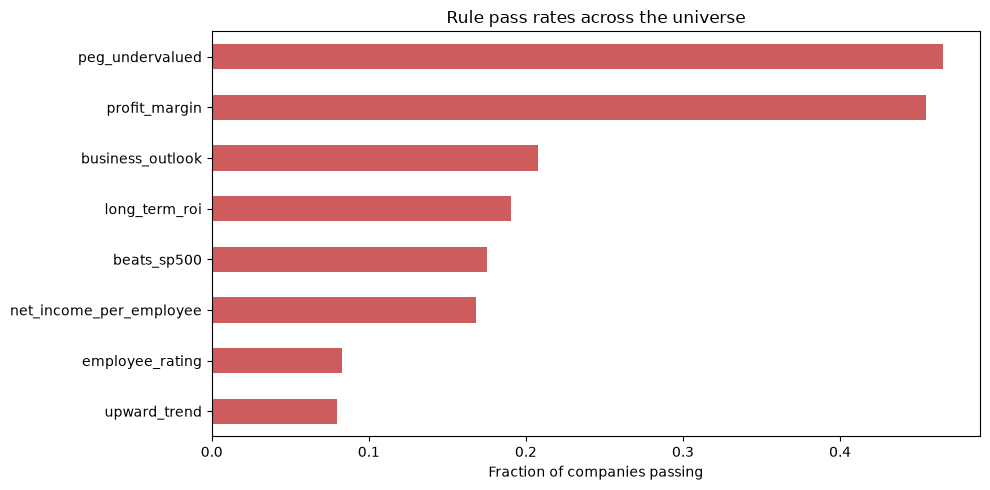

In [6]:
rule_cols = [c for c in screened.columns if c.startswith("rule_")]
pass_rates = screened[rule_cols].mean().sort_values()
pass_rates.index = [c.removeprefix("rule_") for c in pass_rates.index]
ax = pass_rates.plot.barh(color="indianred")
ax.set_title("Rule pass rates across the universe")
ax.set_xlabel("Fraction of companies passing")
plt.tight_layout()
plt.show()

## Takeaways

- The screen compresses ~1,170 companies to a **15-name diligence list**
  using transparent, auditable criteria — every pass/fail is inspectable.
- The hardest rules to pass are valuation (PEG ≤ 1) and market-beating
  returns; quality alone is common, *cheap* quality is rare.
- Hindsight check: the 2020 top tier (AAPL, MSFT, NVDA, ADBE, AMZN...) went
  on to perform well, but that is one draw from one period. Whether rule
  sets like this hold up out-of-sample under transaction costs is exactly
  what the backtesting notebooks (06–08) are for.